# E-Commerce Customer Analysis

In [1]:
import pandas as pd

df = pd.read_csv('D:\Evan\PORTO\market analysis\clean_data.csv', sep=';')
df.head()

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   order_id                            20848 non-null  object
 1   total_qty                           20848 non-null  int64 
 2   total_weight_gr                     20848 non-null  int64 
 3   total_returned_qty                  20848 non-null  int64 
 4   Total Diskon                        20848 non-null  int64 
 5   product_categories                  20848 non-null  object
 6   num_product_categories              20848 non-null  int64 
 7   Status Pesanan                      20848 non-null  object
 8   Alasan Pembatalan                   2830 non-null   object
 9   Opsi Pengiriman                     20848 non-null  object
 10  Metode Pembayaran                   20848 non-null  object
 11  Kota/Kabupaten                      20848 non-null  ob

In [3]:
df.dtypes

order_id                              object
total_qty                              int64
total_weight_gr                        int64
total_returned_qty                     int64
Total Diskon                           int64
product_categories                    object
num_product_categories                 int64
Status Pesanan                        object
Alasan Pembatalan                     object
Opsi Pengiriman                       object
Metode Pembayaran                     object
Kota/Kabupaten                        object
Provinsi                              object
Ongkos Kirim Dibayar oleh Pembeli      int64
Estimasi Potongan Biaya Pengiriman     int64
Total Pembayaran                       int64
Perkiraan Ongkos Kirim                 int64
Waktu Pesanan Dibuat                  object
source_file                           object
dtype: object

In [4]:
df['Waktu Pesanan Dibuat'] = pd.to_datetime(df['Waktu Pesanan Dibuat'])
df.dtypes

order_id                                      object
total_qty                                      int64
total_weight_gr                                int64
total_returned_qty                             int64
Total Diskon                                   int64
product_categories                            object
num_product_categories                         int64
Status Pesanan                                object
Alasan Pembatalan                             object
Opsi Pengiriman                               object
Metode Pembayaran                             object
Kota/Kabupaten                                object
Provinsi                                      object
Ongkos Kirim Dibayar oleh Pembeli              int64
Estimasi Potongan Biaya Pengiriman             int64
Total Pembayaran                               int64
Perkiraan Ongkos Kirim                         int64
Waktu Pesanan Dibuat                  datetime64[ns]
source_file                                   

In [5]:
df['bulanan'] = df['Waktu Pesanan Dibuat'].dt.to_period('M')
df['hour'] = df['Waktu Pesanan Dibuat'].dt.hour
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   order_id                            20848 non-null  object        
 1   total_qty                           20848 non-null  int64         
 2   total_weight_gr                     20848 non-null  int64         
 3   total_returned_qty                  20848 non-null  int64         
 4   Total Diskon                        20848 non-null  int64         
 5   product_categories                  20848 non-null  object        
 6   num_product_categories              20848 non-null  int64         
 7   Status Pesanan                      20848 non-null  object        
 8   Alasan Pembatalan                   2830 non-null   object        
 9   Opsi Pengiriman                     20848 non-null  object        
 10  Metode Pembayaran     

In [6]:
df['is_cancelled'] = df['Status Pesanan'].apply(lambda x: 1 if 'Batal' in str(x) else 0)
df.head()

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,...,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file,bulanan,hour,is_cancelled
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,...,BANTEN,0,10000,38300,10000,2024-04-01 00:15:00,AprilSales2024.xlsx,2024-04,0.0,0
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,...,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47:00,AprilSales2024.xlsx,2024-04,1.0,0
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,...,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25:00,AprilSales2024.xlsx,2024-04,4.0,0
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,...,JAMBI,0,20000,32200,20000,2024-04-01 04:41:00,AprilSales2024.xlsx,2024-04,4.0,0
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,...,BANTEN,0,0,0,8000,2024-04-01 06:12:00,AprilSales2024.xlsx,2024-04,6.0,1


In [7]:
penjualan_bulanan = df.groupby('bulanan')['Total Pembayaran'].sum().reset_index()
penjualan_bulanan['bulanan'] = penjualan_bulanan['bulanan'].astype(str)



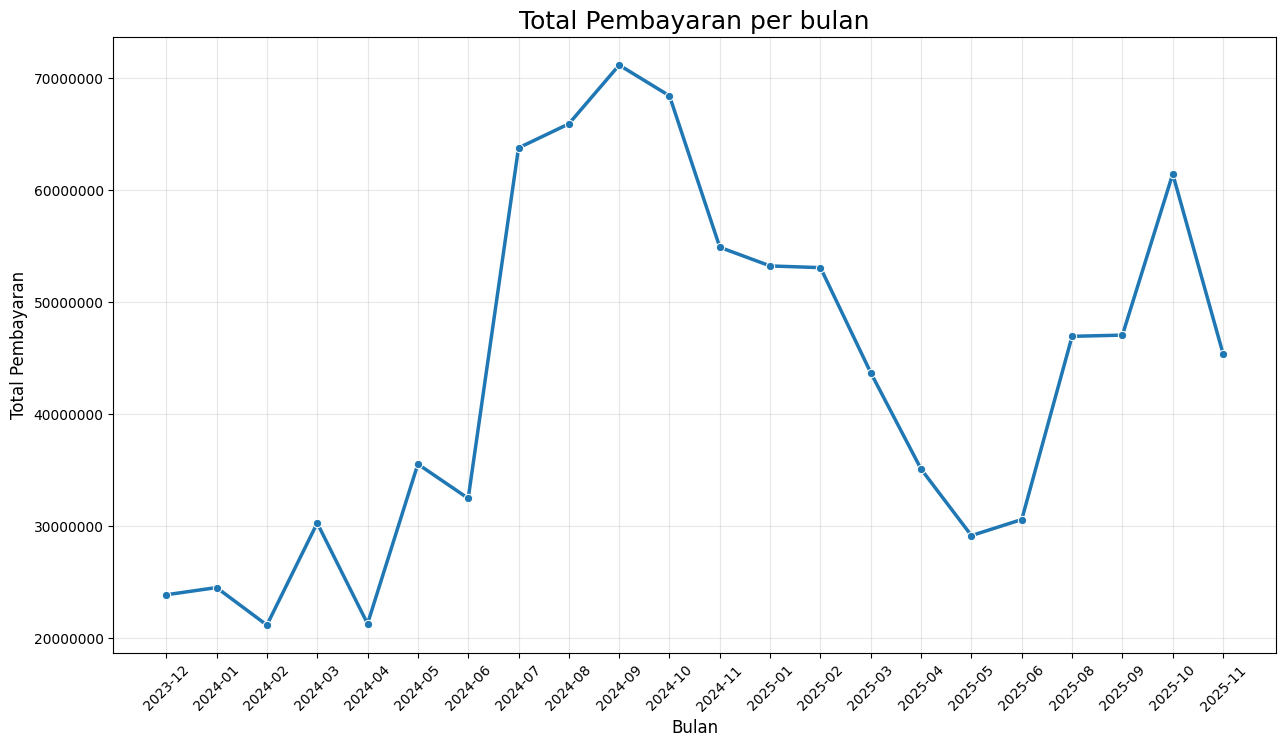

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))
sns.lineplot(data = penjualan_bulanan, x = 'bulanan', y = 'Total Pembayaran', marker = 'o',
             linewidth = 2.5)
plt.title("Total Pembayaran per bulan", fontsize=18)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Pembayaran',fontsize=12)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') # Remove scientific notation
plt.grid(True, alpha=0.3)
plt.show()


In [9]:
pembatalan = df.groupby('Metode Pembayaran')[('is_cancelled')].agg(['mean', 'count'])
pembatalan.columns = ['cancel_rate', 'total_order']
#filter metode pembayaran dengan lebih dari 150 order, karena mau hanya fokus pada metode pembayaran terbanyak saja
pembatalan = pembatalan[pembatalan['total_order'] > 150].sort_values(by='cancel_rate', ascending = False)

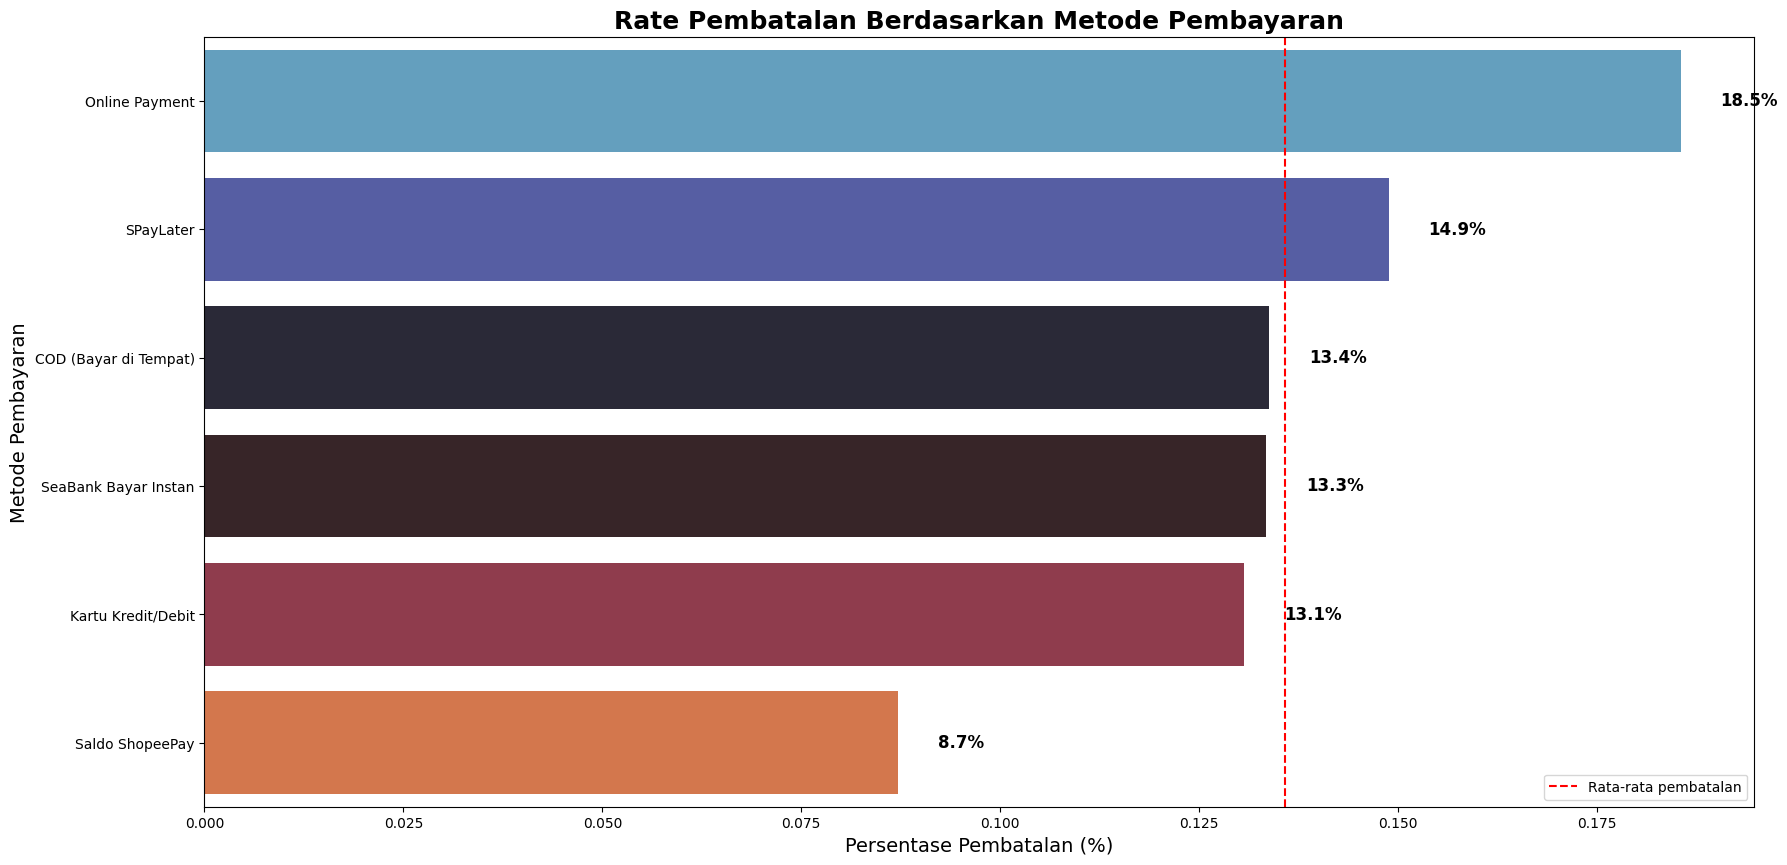

In [10]:
plt.figure(figsize=(20,10))
barplot = sns.barplot (x=pembatalan['cancel_rate'], y=pembatalan.index, palette= 'icefire')

#label
for i, v in enumerate (pembatalan['cancel_rate']):
    barplot.text(v + 0.005, i, f"{v:.1%}", color = 'black', va='center', fontweight='bold', fontsize=12)

plt.title('Rate Pembatalan Berdasarkan Metode Pembayaran', fontsize = 18, fontweight = 'bold')
plt.xlabel('Persentase Pembatalan (%)', fontsize= 14)
plt.ylabel('Metode Pembayaran', fontsize= 14)

#tambah garis rata-rata untuk perbandingan
plt.axvline(df['is_cancelled'].mean(), color = 'red', linestyle = '--', label ='Rata-rata pembatalan')
plt.legend()
plt.show()


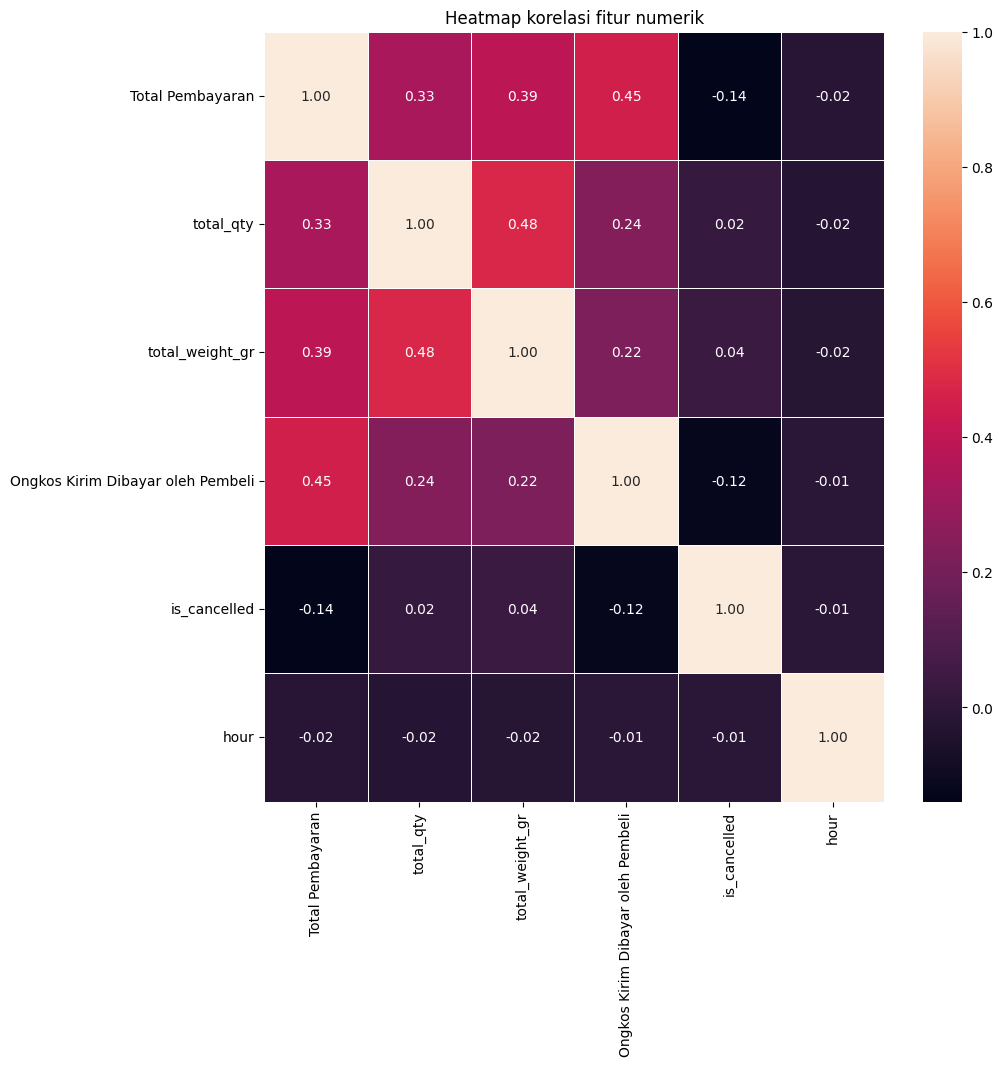

In [11]:
fitur_num = ['Total Pembayaran', 'total_qty', 'total_weight_gr', 'Ongkos Kirim Dibayar oleh Pembeli', 'is_cancelled', 'hour']
corr_matriks = df[fitur_num].corr()

#visualisasi heatmap
plt.figure(figsize=(10,10))
sns.heatmap(corr_matriks, annot=True, fmt='.2f', linewidths=.5)
plt.title('Heatmap korelasi fitur numerik')
plt.show()

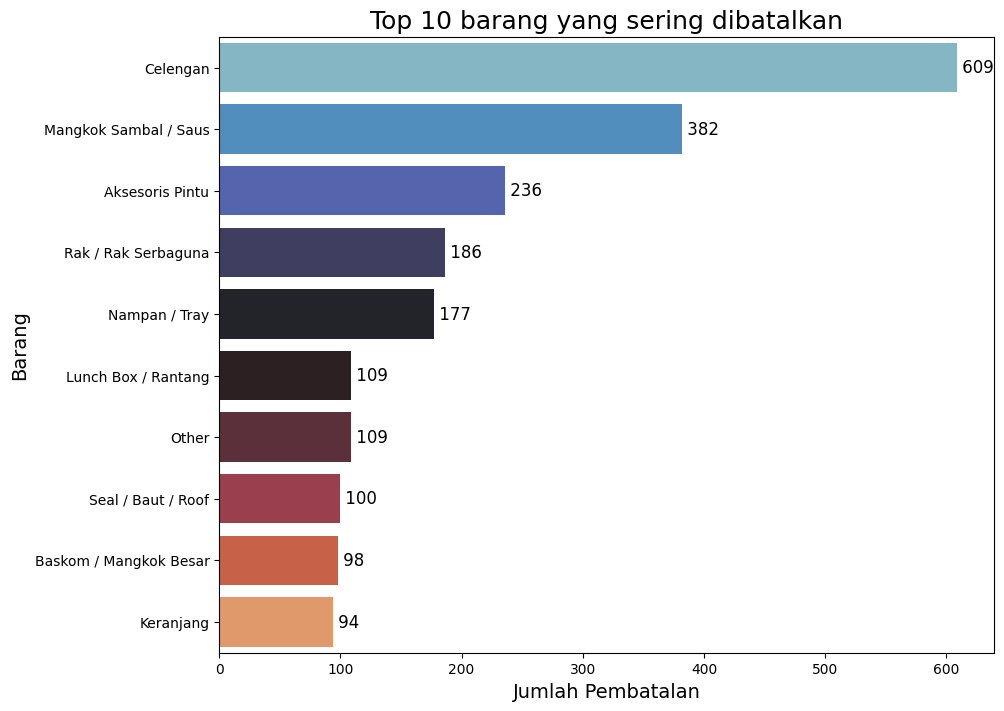

In [12]:
order_batal = df[df['is_cancelled'] == 1]

top_barang_cancel = order_batal['product_categories'].value_counts().head(10)

plt.figure(figsize= (10,8))
sns.barplot(x= top_barang_cancel.values, y=top_barang_cancel.index, palette = 'icefire')

for index, value in enumerate(top_barang_cancel.values):
    plt.text(value, index, f' {value}', va='center', fontsize=12)

plt.title('Top 10 barang yang sering dibatalkan', fontsize = 18)
plt.xlabel('Jumlah Pembatalan', fontsize= 14)
plt.ylabel('Barang', fontsize= 14)
plt.show()

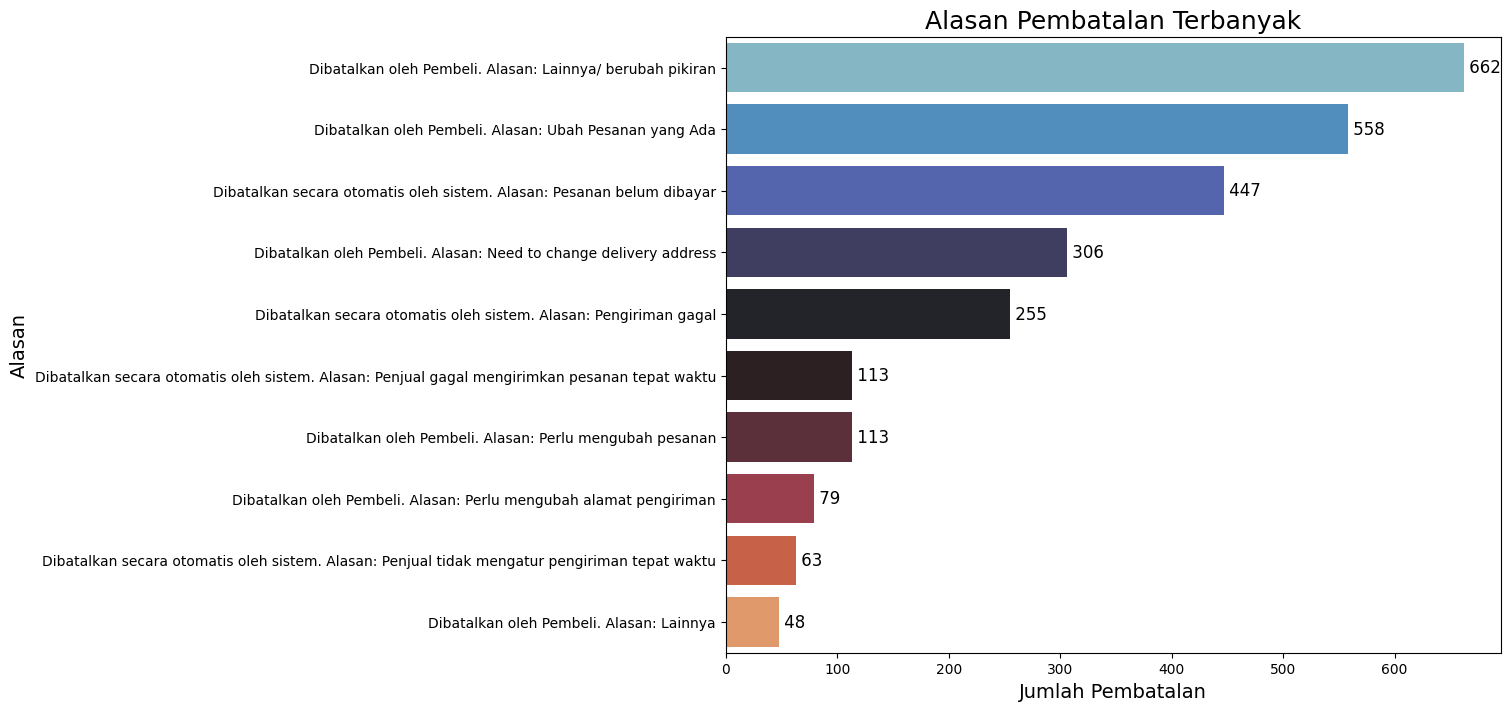

In [13]:
order_batal = df[df['is_cancelled'] == 1]

top_barang_cancel = order_batal['Alasan Pembatalan'].value_counts().head(10)


plt.figure(figsize= (10,8))
sns.barplot(x= top_barang_cancel.values, y=top_barang_cancel.index, palette = 'icefire')

for index, value in enumerate(top_barang_cancel.values):
    plt.text(value, index, f' {value}', va='center', fontsize=12)

plt.title('Alasan Pembatalan Terbanyak', fontsize = 18)
plt.xlabel('Jumlah Pembatalan', fontsize= 14)
plt.ylabel('Alasan', fontsize= 14)
plt.show()

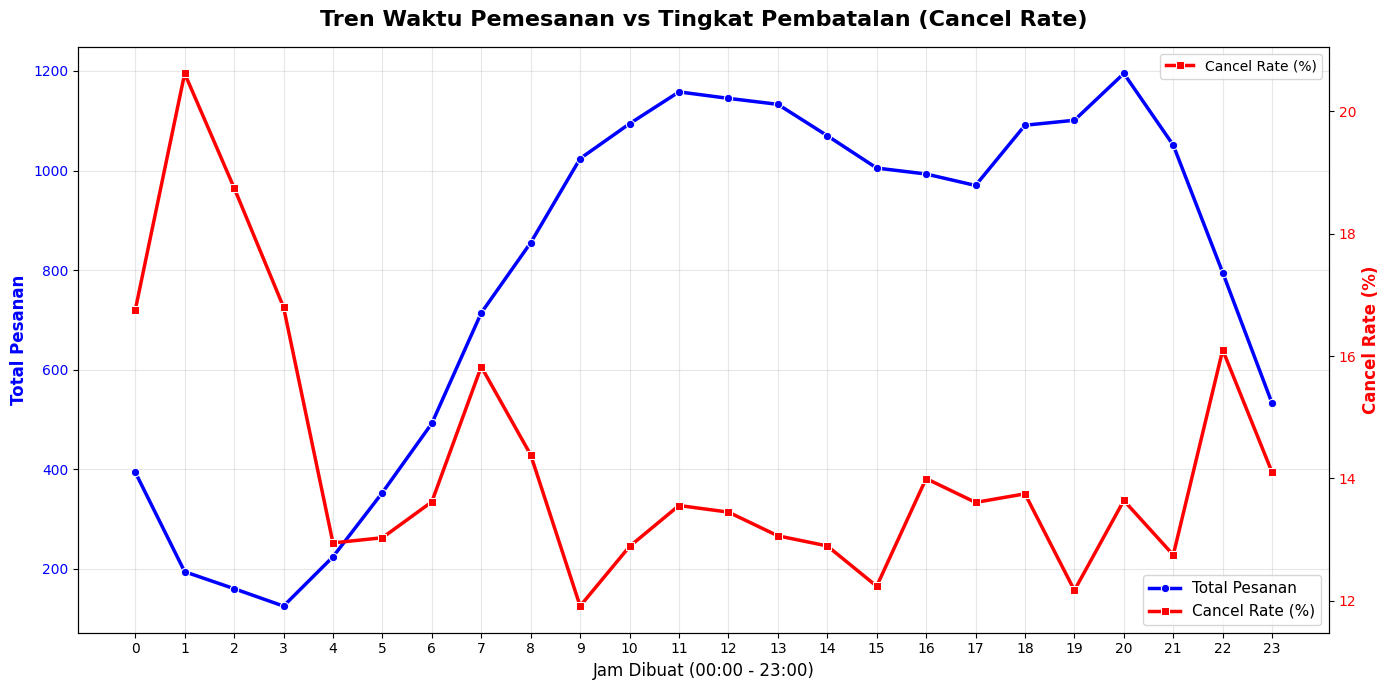

In [14]:


# Agregasi data berdasarkan jam
hourly_stats = df.groupby('hour').agg(
    total_orders=('order_id', 'count'),       # Menghitung total pesanan
    cancelled_orders=('is_cancelled', 'sum')  # Menghitung pesanan yang batal
).reset_index()

#Hitung Cancel Rate (Persentase)
hourly_stats['cancel_rate'] = (hourly_stats['cancelled_orders'] / hourly_stats['total_orders']) * 100

#Visualisasi
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot pertama: Total Pesanan (Sumbu Y kiri)
sns.lineplot(
    data=hourly_stats, x='hour', y='total_orders', 
    marker='o', color='blue', linewidth=2.5, ax=ax1, label='Total Pesanan'
)
ax1.set_xlabel('Jam Dibuat (00:00 - 23:00)', fontsize=12)
ax1.set_ylabel('Total Pesanan', fontsize=12, color='blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(0, 24)) # Memastikan sumbu X menampilkan jam 0-23
ax1.grid(True, alpha=0.3)

# Membuat sumbu Y kedua
ax2 = ax1.twinx()

# Plot kedua: Cancel Rate (Sumbu Y kanan)
sns.lineplot(
    data=hourly_stats, x='hour', y='cancel_rate', 
    marker='s', color='red', linewidth=2.5, ax=ax2, label='Cancel Rate (%)'
)
ax2.set_ylabel('Cancel Rate (%)', fontsize=12, color='red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

# Menyatukan legend dari kedua sumbu agar rapi
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right', fontsize=11)

# Judul Plot
plt.title('Tren Waktu Pemesanan vs Tingkat Pembatalan (Cancel Rate)', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# ML

Classificatoin report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7228
           1       0.98      1.00      0.99      1112

    accuracy                           1.00      8340
   macro avg       0.99      1.00      0.99      8340
weighted avg       1.00      1.00      1.00      8340



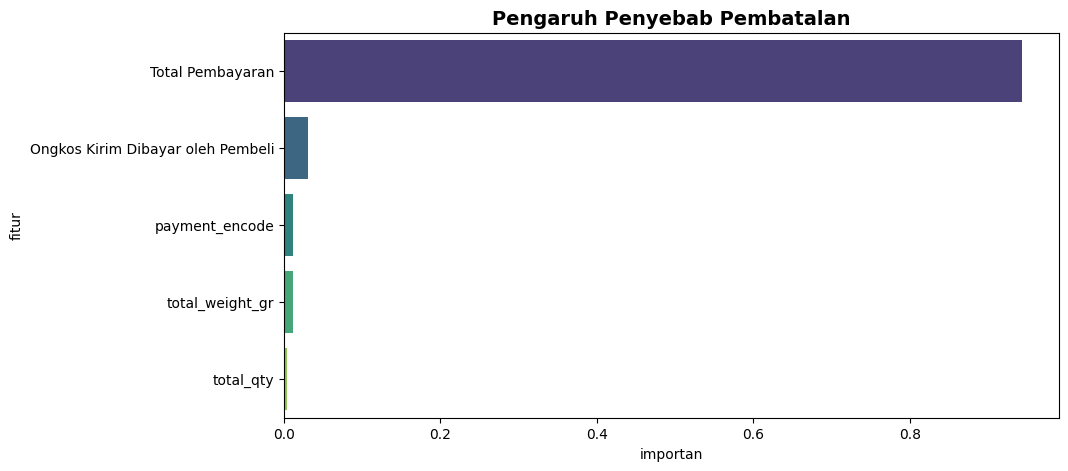

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

df_model = df.dropna(subset=['Total Pembayaran', 'total_qty', 'Metode Pembayaran', 'Provinsi'])
fitur = ['Total Pembayaran', 'total_qty', 'total_weight_gr', 'Ongkos Kirim Dibayar oleh Pembeli']

#encoding
le = LabelEncoder()
df_model['payment_encode'] = le.fit_transform(df_model['Metode Pembayaran'])
fitur.append('payment_encode')

X = df_model[fitur]
y = df_model['is_cancelled']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.4, random_state=12)

rf= RandomForestClassifier(n_estimators=1000, random_state=12)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('Classificatoin report:\n')
print(classification_report(y_test, y_pred))

#fitur penting
importan_fit = pd.DataFrame({
    'fitur' : fitur, 
    'importan' : rf.feature_importances_
}).sort_values('importan', ascending=False)


plt.figure(figsize=(10, 5))
sns.barplot(data=importan_fit, x='importan', y='fitur', palette='viridis')
plt.title('Pengaruh Penyebab Pembatalan', fontsize=14, fontweight='bold')
plt.show()